<a href="https://colab.research.google.com/github/Morsalina/MentalHealthPredictor/blob/main/Mental_Health_Score_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
## import the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [3]:
# load the dataset

dataset = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')
dataset.shape

(5000, 13)

In [4]:
dataset.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
## check for duplicate or null values in this dataset

dataset.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [7]:
dataset.duplicated().sum()

np.int64(2)

EDA of this dataset


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

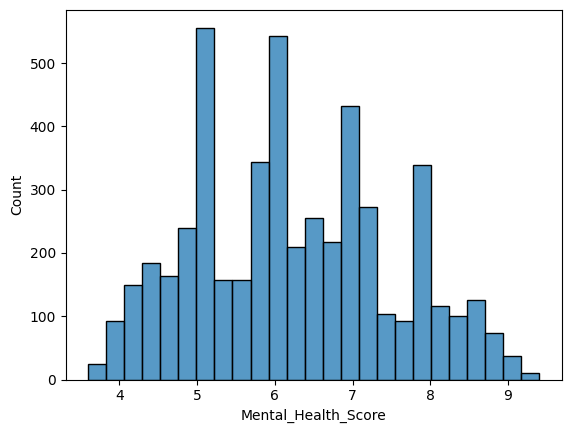

In [8]:
## see the distribution of the output column
sns.histplot(dataset['Mental_Health_Score'])

<Axes: >

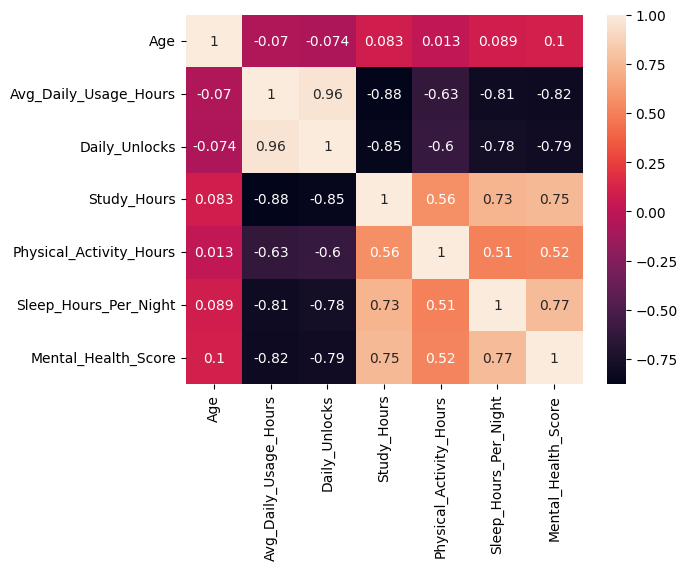

In [9]:
sns.heatmap(dataset.corr(numeric_only= True),annot=True)

In [10]:
dataset

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

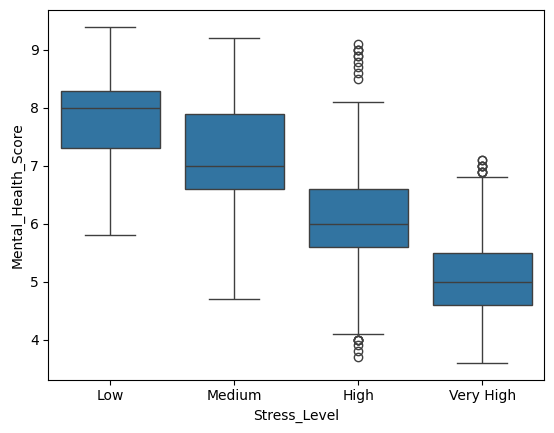

In [11]:
## lets check the correlation of mental health with Stress_Level

dataset['Stress_Level'].unique()
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=dataset, order = order)

We can see there are some outliers from the boxplots. We will remove those outliers when we clean the data.

In [12]:
# we can also check which platforms are the most used ones

dataset['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


## Check the outliers on the numeric features only

In [13]:
numeric_features = dataset.select_dtypes(include = 'number')
numeric_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [14]:
# now we are trying to find the outliers

Q1 = numeric_features.quantile(0.25)
Q3 = numeric_features.quantile(0.75)

IQR = (Q3- Q1)

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = (numeric_features < lower_bound) | (numeric_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


So there are 24 samples that can be considered as outliers.

## Data Cleaning


In [15]:
dataset = dataset.drop_duplicates()
dataset.shape

(4998, 13)

In [16]:
dataset.duplicated().sum()

np.int64(0)

In [17]:
dataset.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


We can see that 'Physical_Activity_Hours' has negative value as mean, which is impossible to have. so we will clip the value to lowest minimum value 0.


In [18]:
dataset['Physical_Activity_Hours'] = dataset['Physical_Activity_Hours'].clip(lower = 0)

/tmp/ipykernel_4028/3043084980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Physical_Activity_Hours'] = dataset['Physical_Activity_Hours'].clip(lower = 0)


In [19]:
dataset.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [20]:
# check if the data is centralized or left/right skewed

numeric_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


For the very engineering we would do in the country column because there the 111 unique contries but very few of them are frequently used. So we would take only those countries that are frequently used because it will reduce the pressure from our models (Though it is not mandatory, I will do it).


Now we will do some feature engineering becuase some of the input columns needs to be modified to get feed into the models.

1. We can see there is one column that is skewed and need to perform log transformation on it.
2. Other numerical columns are okay
3. For the object column, stress level has very important information and the order of the stress level, so we would use ordinal encoding
4. For other object columns, we will just encode them into one-hot vector

In [21]:
top_countries = dataset['Country'].value_counts().index[:10].tolist()

top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [22]:
def grouped_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [23]:
dataset['Country'] = dataset['Country'].apply(grouped_countries)

/tmp/ipykernel_4028/991775725.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Country'] = dataset['Country'].apply(grouped_countries)


In [24]:
dataset

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [25]:
dataset['Country'].value_counts()

,count
Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [26]:
skewed_column = ['Study_Hours']
numeric_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_column = ['Stress_Level']
object_columns = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use']

input_columns = skewed_column + numeric_columns + ordinal_column + object_columns

X = dataset[input_columns]
Y = dataset['Mental_Health_Score']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [27]:
## Now I need to make some pipelines to process the columns so that they can be used to train the model

skewed_pipeline = Pipeline( steps = [
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

numeric_pipeline = Pipeline(steps = [
    ('scale', StandardScaler())
])

ordinal_pipeline = Pipeline(steps = [
    ('encode', OrdinalEncoder(categories=[[ 'Low', 'Medium', 'High', 'Very High']]))
])

object_pipeline = Pipeline(steps = [
    ('encode', OneHotEncoder(handle_unknown = 'ignore'))
])


## Now we need to build a columnTransformer

preprocessor = ColumnTransformer(transformers = [
    ('skewed_pipeline', skewed_pipeline, skewed_column),
    ('numeric_pipeline', numeric_pipeline, numeric_columns),
    ('ordinal_pipeline', ordinal_pipeline, ordinal_column),
    ('object_pipeline', object_pipeline, object_columns)
])

In [30]:
# now build the model pipeline
# model number 1 - linear regression

lr_pipeline = Pipeline(steps= [
    ('preprocessing', preprocessor),
    ('regression_model', LinearRegression())
])

lr_pipeline.fit(X_train, Y_train)
predictions = lr_pipeline.predict(X_test)

## Now evaluate the model result (r2_accuracy)
train_r2_accuracy = r2_score(Y_train, lr_pipeline.predict(X_train))
print(train_r2_accuracy)

test_r2_accuracy = r2_score(Y_test, predictions)
print(test_r2_accuracy)

0.7255672449830839
0.7428129069013331


In [32]:
## model number 2 - random forest

random_forest_pipeline = Pipeline(steps = [
    ('preprocessing', preprocessor),
    ('random_forest', RandomForestRegressor())
])

random_forest_pipeline.fit(X_train, Y_train)
rf_predictions = random_forest_pipeline.predict(X_test)

rf_r2_training_accuracy = r2_score(Y_train, random_forest_pipeline.predict(X_train))
print(rf_r2_training_accuracy)

rf_r2_test_accuracy = r2_score(Y_test, rf_predictions)
print(rf_r2_test_accuracy)



0.9825342419892037
0.8867967400219653


As training accuracy is far greater than the test accuracy, we will finetune the random_forest model so that testing accuracy increases
